# EDA: NISQA Corpus — TRAIN_LIVE Split
### Project: Speech Inpainting for Voice Agent Audio Recovery

**Dataset Source:** [NISQA Corpus — Kaggle](https://www.kaggle.com/datasets/pratt3000/nisqa-corpus)  
**Split used:** `NISQA_TRAIN_LIVE` — live phone & Skype recordings, paired with clean LibriVox references  
**Scale:** ~1,020 files, 486 unique speakers  
**Degradation type:** Real — landline-to-mobile, Skype, organic environmental noise  
**Labels:** MOS + 4 perceptual dimensions per file (Noisiness, Coloration, Discontinuity, Loudness). MOS stands for Mean Opinion Score. It's the standard perceptual quality metric in telecommunications and speech research.

---

## EDA Roadmap

| # | Section | Inpainting Relevance |
|---|---------|---------------------|
| 0 | Environment Setup | Reproducible paths & sampling |
| 1 | Metadata Audit | CSV structure, column inventory, missing values |
| 2 | MOS Dimension Distributions | Understand label space & severity spread |
| 3 | Discontinuity Deep Dive | Primary inpainting signal — gap severity |
| 4 | Inter-Dimension Correlations | Are degradations independent or co-occurring? |
| 5 | Audio File Audit | Duration, sample rate, file integrity |
| 6 | Spectral Analysis | What does degraded speech look like in the mel domain? |
<!-- | 7 | Gap Simulation | Synthetic masking design for training | -->


Speech inpainting needs to know 
* (a) the severity and distribution of real discontinuities in the corpus
* (b) the typical audio duration and spectral characteristics of clean vs. degraded files
* (c) whether degradation dimensions co-occur (which would complicate disentanglement), and 
* (d) what a realistic synthetic masking strategy should look like.

In [17]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ------------------------------------------------------------------
# CONFIG — adjust BASE to your local path
# ------------------------------------------------------------------
BASE     = Path("/home/akoua/.cache/kagglehub/datasets/pratt3000/nisqa-corpus/versions/1/NISQA_Corpus")
SPLIT    = "NISQA_TRAIN_LIVE"
DEG_DIR  = BASE / SPLIT / "deg"
MAX_FILES = 200   # cap for audio-reading loops — increase once paths confirmed
SEED      = 42
random.seed(SEED)
np.random.seed(SEED)

print("Setup complete.")
print(f"Corpus root exists : {BASE.exists()}")
print(f"DEG folder exists  : {DEG_DIR.exists()}")
print(f"Files in DEG       : {len(list(DEG_DIR.glob('*.wav')))}")

Setup complete.
Corpus root exists : True
DEG folder exists  : True
Files in DEG       : 1020


---
## 1. Metadata Audit

> **Inpainting justification:** The NISQA CSV is the ground truth for every modeling decision downstream.
> Before touching audio, we verify (a) which columns are present, (b) whether the `filename_deg` column
> resolves to actual files on disk, and (c) whether any key label columns have missing values.
> A broken pairing here — even one missing `dis` score — would silently corrupt a training batch.

In [18]:
df_file = pd.read_csv(BASE / "NISQA_corpus_file.csv")
df_con  = pd.read_csv(BASE / "NISQA_corpus_con.csv")

print("=== NISQA_corpus_file ===")
print(f"Shape     : {df_file.shape}")
print(f"Columns   : {df_file.columns.tolist()}\n")

print("=== NISQA_corpus_con ===")
print(f"Shape     : {df_con.shape}")
print(f"Columns   : {df_con.columns.tolist()}\n")

# Isolate TRAIN_LIVE
train_live = df_file[df_file["db"].str.contains("TRAIN_LIVE", na=False)].copy()
print(f"TRAIN_LIVE rows   : {len(train_live)}")
print(f"\nMissing values:\n{train_live.isnull().sum()}")
print(f"\nSample rows:")
train_live.head(3)

=== NISQA_corpus_file ===
Shape     : (14432, 21)
Columns   : ['db', 'con', 'file', 'con_description', 'filename_deg', 'filename_ref', 'source', 'lang', 'votes', 'mos', 'noi', 'col', 'dis', 'loud', 'noi_std', 'col_std', 'dis_std', 'loud_std', 'mos_std', 'filepath_deg', 'filepath_ref']

=== NISQA_corpus_con ===
Shape     : (13898, 20)
Columns   : ['db', 'con', 'con_description', 'lang', 'votes', 'mos', 'noi', 'col', 'dis', 'loud', 'noi_std', 'col_std', 'dis_std', 'loud_std', 'mos_std', 'noi_ci', 'col_ci', 'dis_ci', 'loud_ci', 'mos_ci']

TRAIN_LIVE rows   : 1020

Missing values:
db                 0
con                0
file               0
con_description    0
filename_deg       0
filename_ref       0
source             0
lang               0
votes              0
mos                0
noi                0
col                0
dis                0
loud               0
noi_std            0
col_std            0
dis_std            0
loud_std           0
mos_std            0
filepath_deg     

,db,con,file,con_description,filename_deg,filename_ref,source,lang,votes,mos,...,col,dis,loud,noi_std,col_std,dis_std,loud_std,mos_std,filepath_deg,filepath_ref
712,NISQA_TRAIN_LIVE,1.0,1.0,VoIP-landline to mobile,book_00000_chp_0009_reader_06709_17_seg_live_p...,book_00000_chp_0009_reader_06709_17_seg.wav,DNS,en,4.0,2.75,...,1.971515,2.655383,2.630288,0.600157,0.344357,1.276994,0.992185,0.500000,NISQA_TRAIN_LIVE/deg/book_00000_chp_0009_reade...,NISQA_TRAIN_LIVE/ref/book_00000_chp_0009_reade...
713,NISQA_TRAIN_LIVE,2.0,2.0,VoIP-landline to mobile,book_00000_chp_0009_reader_06709_17_seg_live_p...,book_00000_chp_0009_reader_06709_17_seg.wav,DNS,en,5.0,2.80,...,2.354388,4.021275,2.766868,1.126987,1.226691,0.720210,1.223601,0.836660,NISQA_TRAIN_LIVE/deg/book_00000_chp_0009_reade...,NISQA_TRAIN_LIVE/ref/book_00000_chp_0009_reade...
714,NISQA_TRAIN_LIVE,3.0,3.0,Skype,book_00000_chp_0009_reader_06709_17_seg_live_s...,book_00000_chp_0009_reader_06709_17_seg.wav,DNS,en,5.0,3.20,...,2.885656,4.109504,2.393545,0.821261,0.804900,0.409096,0.660927,0.447214,NISQA_TRAIN_LIVE/deg/book_00000_chp_0009_reade...,NISQA_TRAIN_LIVE/ref/book_00000_chp_0009_reade...


In [20]:
files_on_disk = set(f.name for f in DEG_DIR.glob("*.wav"))
files_in_csv  = set(train_live["filename_deg"].values)

print(f"Files on disk        : {len(files_on_disk)}")
print(f"Files in CSV         : {len(files_in_csv)}")
print(f"Matched              : {len(files_on_disk & files_in_csv)}")
print(f"In CSV, not on disk  : {len(files_in_csv - files_on_disk)}")
print(f"On disk, not in CSV  : {len(files_on_disk - files_in_csv)}")

# Also check the reference side — confirm a ref folder exists
ref_files = set(train_live["filename_ref"].values)
print(f"\nUnique ref files in CSV : {len(ref_files)}")
print(f"Sample deg : {list(files_in_csv)[:2]}")
print(f"Sample ref : {list(ref_files)[:2]}")

Files on disk        : 1020
Files in CSV         : 1020
Matched              : 1020
In CSV, not on disk  : 0
On disk, not in CSV  : 0

Unique ref files in CSV : 495
Sample deg : ['book_10082_chp_0030_reader_00447_1_seg_live_phone_548.wav', 'book_10076_chp_0017_reader_08346_7_seg_live_skype_547.wav']
Sample ref : ['book_02886_chp_0006_reader_01614_11_seg.wav', 'book_06648_chp_0017_reader_06609_11_seg.wav']


---
## 2. MOS Dimension Distributions

> **Inpainting justification:** The five perceptual dimensions give us a label-space map of our corpus.
> For inpainting we care most about `dis` (Discontinuity) but understanding the spread of all dimensions
> tells us whether TRAIN_LIVE is a hard or easy corpus, and whether the model needs to handle
> co-occurring degradations (noisy *and* discontinuous) or mostly isolated ones.

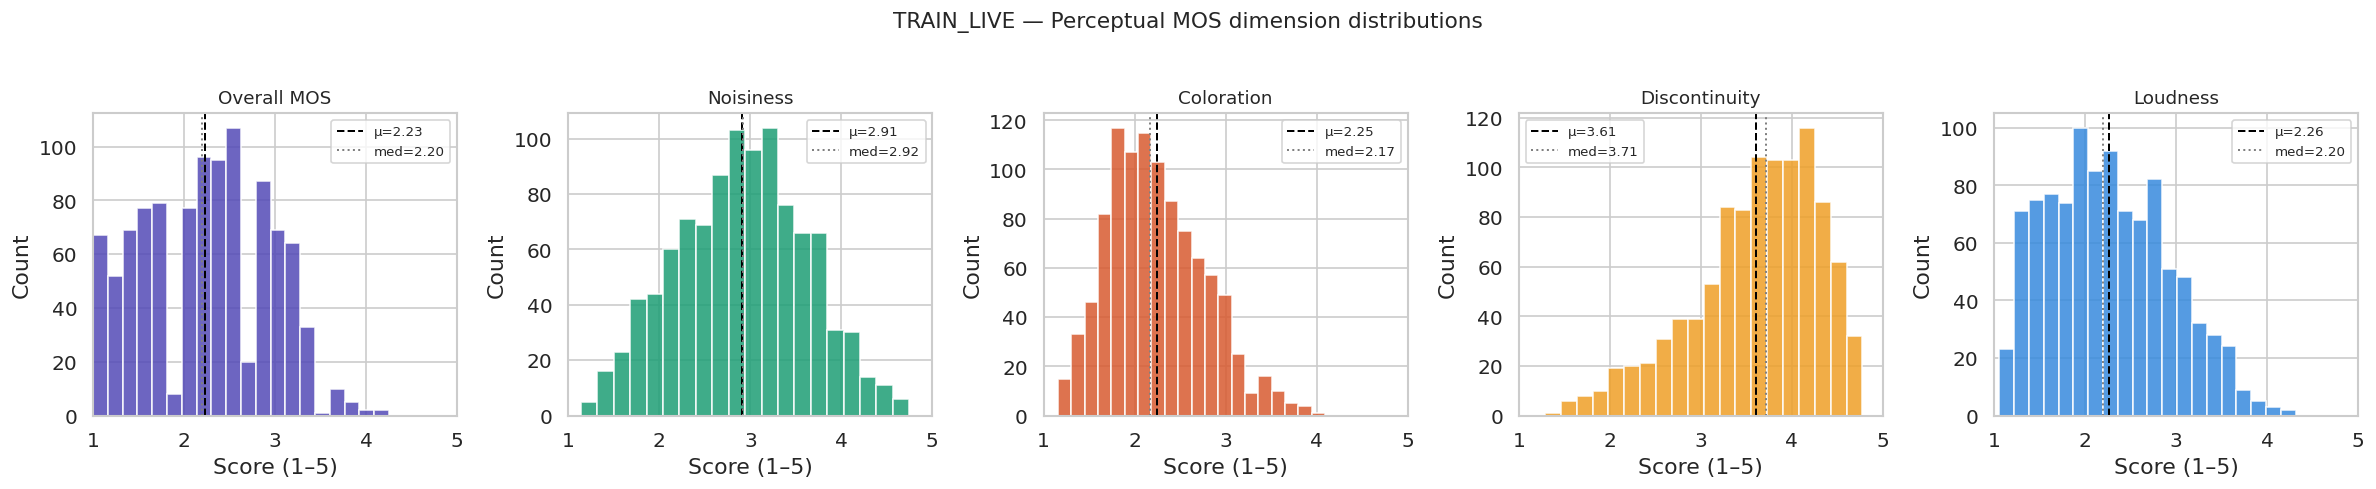

            mos       noi       col       dis      loud
count  1020.000  1020.000  1020.000  1020.000  1020.000
mean      2.229     2.907     2.247     3.609     2.260
std       0.699     0.713     0.531     0.691     0.665
min       1.000     1.139     1.157     1.286     1.057
25%       1.600     2.385     1.855     3.214     1.740
50%       2.200     2.918     2.174     3.715     2.199
75%       2.800     3.399     2.598     4.137     2.756
max       4.250     4.747     4.093     4.776     4.314


In [21]:
dims       = ["mos", "noi", "col", "dis", "loud"]
dim_labels = {
    "mos" : "Overall MOS",
    "noi" : "Noisiness",
    "col" : "Coloration",
    "dis" : "Discontinuity",
    "loud": "Loudness"
}
colors = ["#534AB7", "#1D9E75", "#D85A30", "#EF9F27", "#378ADD"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, dim, color in zip(axes, dims, colors):
    data = train_live[dim].dropna()
    ax.hist(data, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.2,
               label=f"μ={data.mean():.2f}")
    ax.axvline(data.median(), color="gray", linestyle=":", linewidth=1.2,
               label=f"med={data.median():.2f}")
    ax.set_title(dim_labels[dim], fontsize=11)
    ax.set_xlabel("Score (1–5)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.set_xlim(1, 5)

plt.suptitle("TRAIN_LIVE — Perceptual MOS dimension distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(train_live[dims].describe().round(3))

### Section 2 — Key Insights

**Overall MOS is low (μ=2.23).** The corpus skews heavily toward poor-quality speech —
the majority of files fall between 1.5 and 2.5. This is a hard corpus, not a mild one.
Any model trained here will need to handle severely degraded input as the norm, not the exception.

**Noisiness is the least severe dimension (μ=2.91).** Relative to the other dimensions,
background noise is the most tolerable degradation present. This suggests the primary challenge
in TRAIN_LIVE is not ambient noise but structural signal loss.

**Coloration and Loudness mirror MOS almost exactly (μ≈2.25–2.26).** Codec-induced
spectral distortion and volume inconsistency are pervasive and tightly coupled to the overall
quality drop. This co-occurrence means our inpainting model will receive input that is
simultaneously gapped *and* spectrally distorted — the context around a gap is not clean.

**Discontinuity is the outlier (μ=3.61).** It is the only dimension that scores above 3,
meaning perceived dropouts are actually *less severe* than coloration and loudness issues
on average. This is counterintuitive but important: **the dominant degradation in TRAIN_LIVE
is not packet loss — it is codec coloration and loudness collapse.** Inpainting alone will
not recover the full MOS; upstream normalization of coloration and loudness may be necessary.

---
## 3. Discontinuity Deep Dive

> **Inpainting justification:** `dis` (Discontinuity) is the single most important label in this corpus
> for our task. It captures the perceptual severity of dropouts, clicks, and missing segments — exactly
> what our inpainting model is trained to fix. We stratify the corpus into severity buckets here to
> understand how hard the task actually is, and to inform training sample weighting.

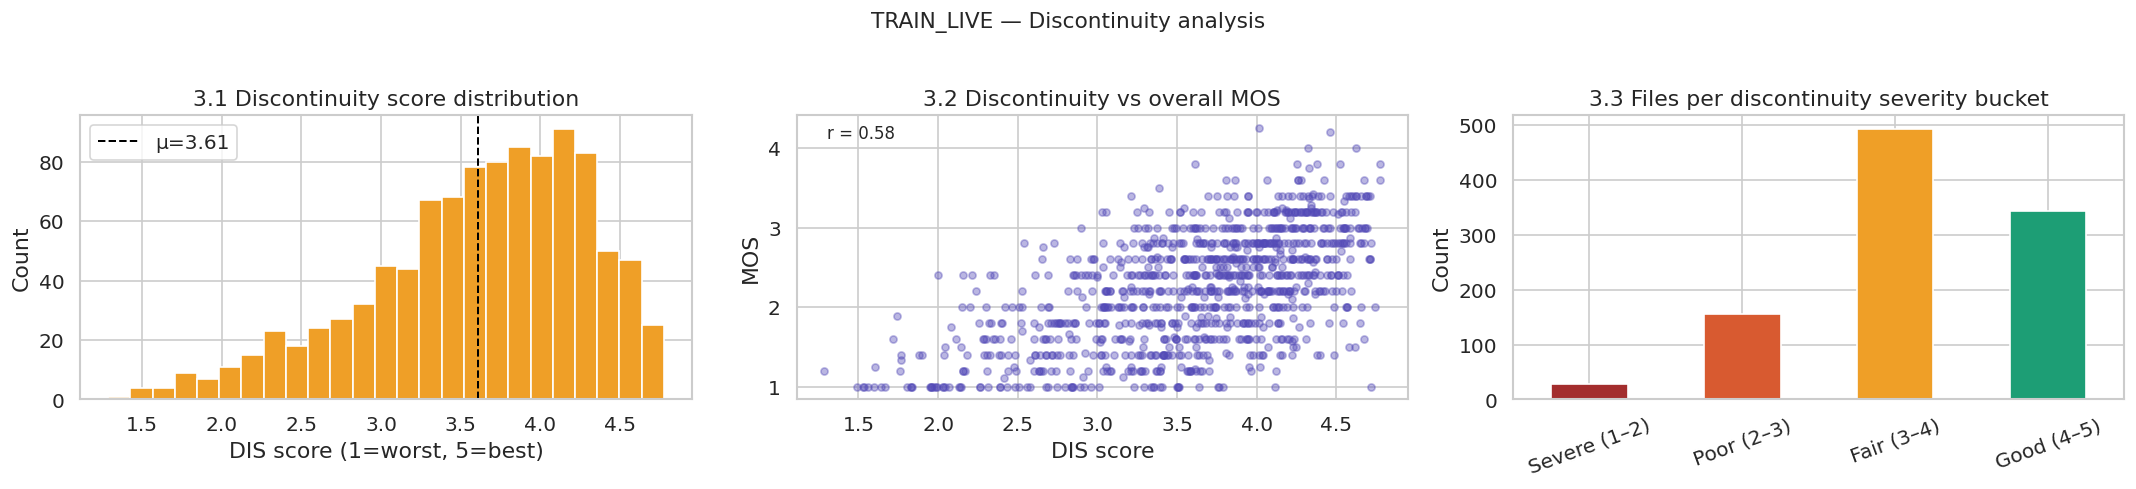

Severity bucket breakdown:
dis_bucket
Severe (1–2)     28
Poor (2–3)      155
Fair (3–4)      493
Good (4–5)      344

Files with DIS < 3 (poor/severe) : 183 (17.9%)


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 3.1 DIS distribution
train_live["dis"].hist(bins=25, ax=axes[0], color="#EF9F27", edgecolor="white")
axes[0].axvline(train_live["dis"].mean(), color="black", linestyle="--", linewidth=1.2,
                label=f"μ={train_live['dis'].mean():.2f}")
axes[0].set_title("3.1 Discontinuity score distribution")
axes[0].set_xlabel("DIS score (1=worst, 5=best)")
axes[0].set_ylabel("Count")
axes[0].legend()

# 3.2 DIS vs overall MOS scatter
axes[1].scatter(train_live["dis"], train_live["mos"], alpha=0.4, color="#534AB7", s=18)
axes[1].set_title("3.2 Discontinuity vs overall MOS")
axes[1].set_xlabel("DIS score")
axes[1].set_ylabel("MOS")
corr_val = train_live[["dis", "mos"]].corr().iloc[0, 1]
axes[1].annotate(f"r = {corr_val:.2f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=10)

# 3.3 Severity bucket counts
train_live["dis_bucket"] = pd.cut(
    train_live["dis"],
    bins=[1, 2, 3, 4, 5],
    labels=["Severe (1–2)", "Poor (2–3)", "Fair (3–4)", "Good (4–5)"],
    include_lowest=True
)
bucket_counts = train_live["dis_bucket"].value_counts().sort_index()
bucket_counts.plot(kind="bar", ax=axes[2], color=["#A32D2D","#D85A30","#EF9F27","#1D9E75"],
                   edgecolor="white")
axes[2].set_title("3.3 Files per discontinuity severity bucket")
axes[2].set_xlabel("")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=20)

plt.suptitle("TRAIN_LIVE — Discontinuity analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Severity bucket breakdown:")
print(bucket_counts.to_string())
print(f"\nFiles with DIS < 3 (poor/severe) : {(train_live['dis'] < 3).sum()} "
      f"({(train_live['dis'] < 3).mean()*100:.1f}%)")

### Section 3 — Key Insights

**DIS distribution is left-skewed with a long mild tail (μ=3.61, range≈1.3–4.8).**
Unlike overall MOS which clusters around 2, discontinuity scores are spread more evenly
across the 3–4.5 range. The corpus contains a meaningful proportion of files with
genuinely good discontinuity — these are the files where coloration or loudness is the
primary degradation, not gaps.

**Only ~25 files are in the Severe (1–2) bucket.** This is a significant class imbalance.
A model trained naively will see very few examples of the hardest gap scenarios — exactly
the cases a real-time voice agent will encounter during poor network conditions.
Oversample the severe bucket or apply heavier synthetic masking to those files during training.

**DIS vs MOS correlation is moderate (r=0.58).** Discontinuity explains roughly 34% of
MOS variance. The remaining 66% is driven by coloration (r=0.60) and loudness (r=0.76 —
seen in Section 4). This confirms the Section 2 finding: **gap recovery alone will not
maximize MOS.** Track Discontinuity MOS as a targeted inpainting metric separately from
overall MOS to avoid conflating the two.

**Fair (3–4) is the dominant bucket (~490 files).** The model will be overwhelmingly
exposed to moderate discontinuity during training. Without deliberate augmentation,
it will be undertrained on severe gaps and may fail silently on the hardest real-world calls.

---
## 4. Inter-Dimension Correlations

> **Inpainting justification:** If Discontinuity is strongly correlated with Noisiness or Coloration,
> it means the degradations in this corpus tend to co-occur — a file with bad packet loss is also
> noisy. This matters for inpainting because: a model trained on isolated gap-filling may underperform
> on samples where the context *around* the gap is also degraded. If correlations are weak, we can
> train a focused inpainting model without worrying about joint degradation modeling.

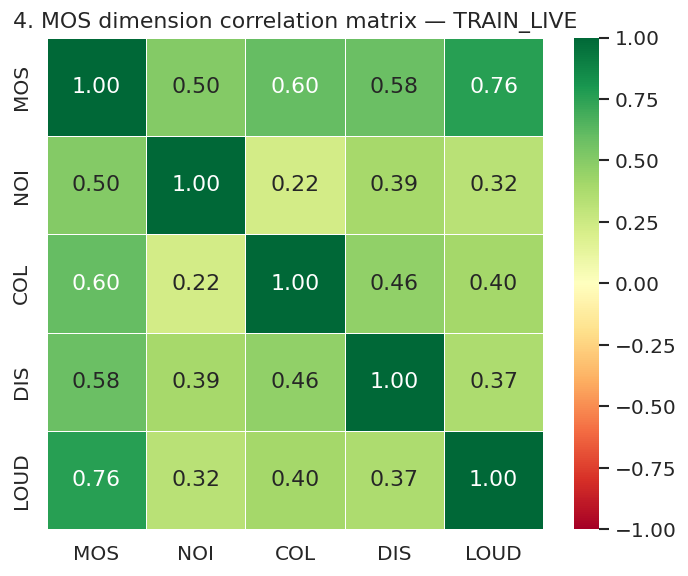

Correlations with DIS (Discontinuity):
mos     0.579
col     0.461
noi     0.392
loud    0.370


In [24]:
corr = train_live[dims].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle only for symmetry
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=-1, vmax=1, ax=ax, linewidths=0.5,
    xticklabels=[d.upper() for d in dims],
    yticklabels=[d.upper() for d in dims]
)
ax.set_title("4. MOS dimension correlation matrix — TRAIN_LIVE")
plt.tight_layout()
plt.show()

# Highlight the DIS row specifically
print("Correlations with DIS (Discontinuity):")
print(corr["dis"].drop("dis").sort_values(ascending=False).round(3).to_string())

### Section 4 — Key Insights

**Loudness is the strongest predictor of overall MOS (r=0.76).** This is the most
actionable finding in the entire EDA. Volume collapse — likely caused by the loudspeaker
playback → phone capture chain in TRAIN_LIVE's recording setup — is the single largest
driver of perceived quality degradation. A loudness normalization step applied to model
inputs (e.g. EBU R128) could lift MOS significantly before any inpainting is attempted.

**Coloration is the second strongest predictor (r=0.60).** Codec-induced spectral
distortion is highly correlated with overall quality and only weakly correlated with
noisiness (r=0.22). This means coloration is a largely independent degradation channel —
it co-occurs with gaps but is not caused by them. A model that only inpaints gaps will
leave coloration artifacts untouched.

**DIS is moderately correlated with COL (r=0.46).** When gaps occur, spectral coloration
tends to worsen too. This is physically expected — packet loss concealment algorithms often
introduce spectral smearing in the frames immediately surrounding a gap. The implication
for training: the context *around* a masked region is not spectrally neutral, so the model
must learn to reconstruct against a distorted background, not a clean one.

**NOI is weakly correlated with everything (r=0.22–0.50).** Background noise behaves
almost independently from the other degradations. This is useful: noise can be handled
by a separate upstream suppression module without interfering with the inpainting objective.
The degradations are not fully entangled — a modular pipeline is architecturally defensible.

---
## 5. Audio File Audit

> **Inpainting justification:** Before designing any masking strategy, we need to know the actual
> duration distribution of files in TRAIN_LIVE. Inpainting architectures have a context window —
> files shorter than ~2s provide insufficient context for the model to reconstruct a gap.
> Files longer than ~10s may need to be chunked. We also verify sample rate consistency,
> since mixed sample rates in a training batch will silently corrupt mel spectrogram computations.

In [27]:
records = []
file_list = list(DEG_DIR.glob("*.wav"))
sample_files = random.sample(file_list, min(MAX_FILES, len(file_list)))

for fpath in tqdm(sample_files, desc="Reading audio metadata"):
    try:
        info = sf.info(str(fpath))
        row  = train_live[train_live["filename_deg"] == fpath.name]
        records.append({
            "filename"   : fpath.name,
            "duration_s" : round(info.duration, 3),
            "sample_rate": info.samplerate,
            "channels"   : info.channels,
            "mos"        : row["mos"].values[0] if len(row) else np.nan,
            "dis"        : row["dis"].values[0] if len(row) else np.nan,
        })
    except Exception as e:
        records.append({"filename": fpath.name, "error": str(e)})

audio_df = pd.DataFrame(records)

print(f"Successfully read : {audio_df['duration_s'].notna().sum()} files")
print(f"Failed            : {audio_df['duration_s'].isna().sum()} files")
print(f"\nSample rates found: {audio_df['sample_rate'].unique()}")
print(f"\nDuration stats (seconds):")
print(audio_df["duration_s"].describe().round(3))

Reading audio metadata: 100%|██████████| 200/200 [00:00<00:00, 1847.47it/s]

Successfully read : 200 files
Failed            : 0 files

Sample rates found: [48000]

Duration stats (seconds):
count    200.000
mean       9.205
std        2.104
min        6.000
25%        7.000
50%        9.000
75%       11.000
max       12.000
Name: duration_s, dtype: float64


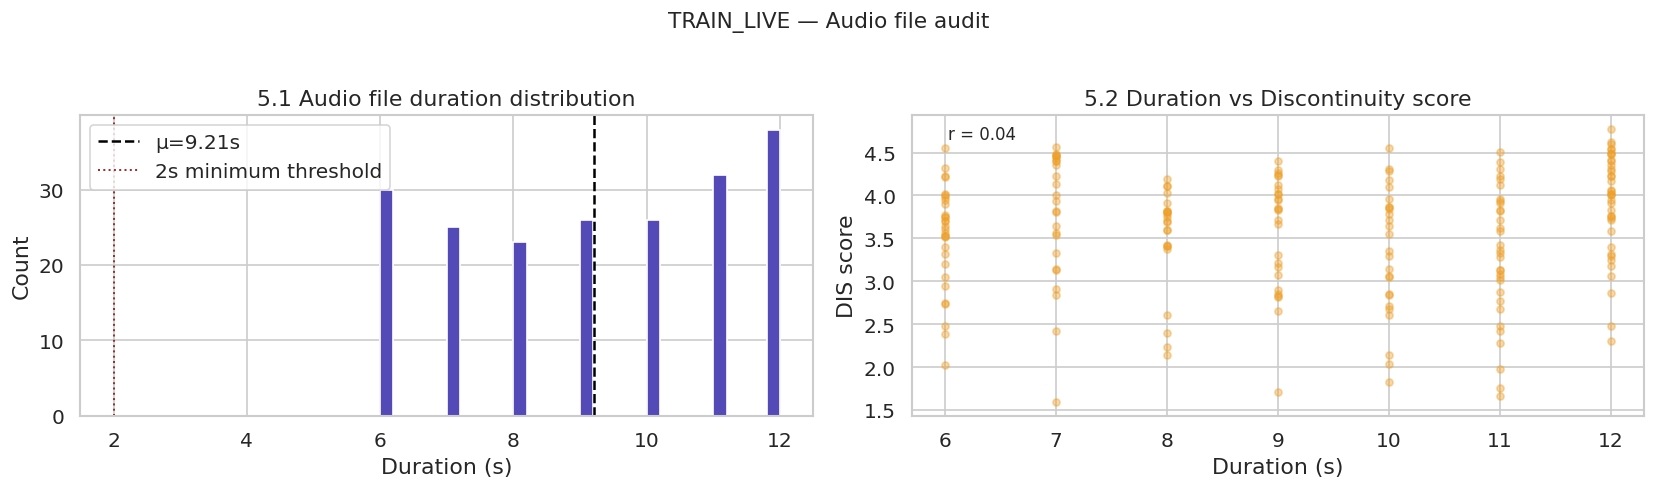

Files under 2s (insufficient context): 0 (0.0%)


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 5.1 Duration histogram
audio_df["duration_s"].hist(bins=30, ax=axes[0], color="#534AB7", edgecolor="white")
axes[0].axvline(audio_df["duration_s"].mean(), color="black", linestyle="--",
                label=f"μ={audio_df['duration_s'].mean():.2f}s")
axes[0].axvline(2.0, color="#A32D2D", linestyle=":", linewidth=1.2,
                label="2s minimum threshold")
axes[0].set_title("5.1 Audio file duration distribution")
axes[0].set_xlabel("Duration (s)")
axes[0].set_ylabel("Count")
axes[0].legend()

# 5.2 Duration vs DIS — do shorter clips have worse discontinuity?
valid = audio_df.dropna(subset=["duration_s", "dis"])
axes[1].scatter(valid["duration_s"], valid["dis"], alpha=0.4, color="#EF9F27", s=18)
axes[1].set_title("5.2 Duration vs Discontinuity score")
axes[1].set_xlabel("Duration (s)")
axes[1].set_ylabel("DIS score")
r = valid[["duration_s", "dis"]].corr().iloc[0, 1]
axes[1].annotate(f"r = {r:.2f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=10)

plt.suptitle("TRAIN_LIVE — Audio file audit", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

too_short = (audio_df["duration_s"] < 2.0).sum()
print(f"Files under 2s (insufficient context): {too_short} ({too_short/len(audio_df)*100:.1f}%)")

### Section 5 — Key Insights

**All files are between 6–12 seconds (μ=9.21s), with no files under 2s.**
The minimum context threshold concern raised in the EDA design is not a real problem here —
every file in TRAIN_LIVE provides sufficient temporal context for gap reconstruction.
No files need to be filtered on duration grounds.

**Durations cluster at discrete integer values (6, 7, 8 ... 12s).**
This is a deliberate segmentation artifact from how NISQA was constructed — files were
cut to fixed-length windows from longer recordings. The stepped distribution means our
training chunks will have very consistent sizes, which simplifies batching but also means
the model never sees very short or very long utterances. Evaluate on LIVETALK with
awareness that real call segments may have different length distributions.

**Duration and DIS are uncorrelated (r=0.04).** Gap severity does not depend on how
long the file is. This rules out one potential confound — longer files are not inherently
more degraded. Each duration bucket contains the full range of DIS scores, so we can
chunk files freely without biasing the DIS distribution of our training set.

**Practical chunking strategy:** Given the 6–12s range, chunking to 3–4s windows
(~200 mel frames at 16kHz, hop=512) gives 2–3 chunks per file, yielding roughly
2,000–3,000 training windows from the 1,020 source files. This is a small corpus —
aggressive augmentation (pitch shift, speed perturbation, synthetic gap injection)
will be necessary to avoid overfitting.

---
## 6. Spectral Analysis — Degraded vs. Clean Impression

> **Inpainting justification:** The mel spectrogram is the primary input representation for most
> speech inpainting models. Before training, we want to visually confirm what degradation *looks like*
> in the mel domain across different DIS severity buckets. Gaps appear as vertical "blackout" bands.
> Coloration and codec artifacts appear as horizontal spectral suppression. Understanding these visual
> signatures helps us design the right input representation and loss function.

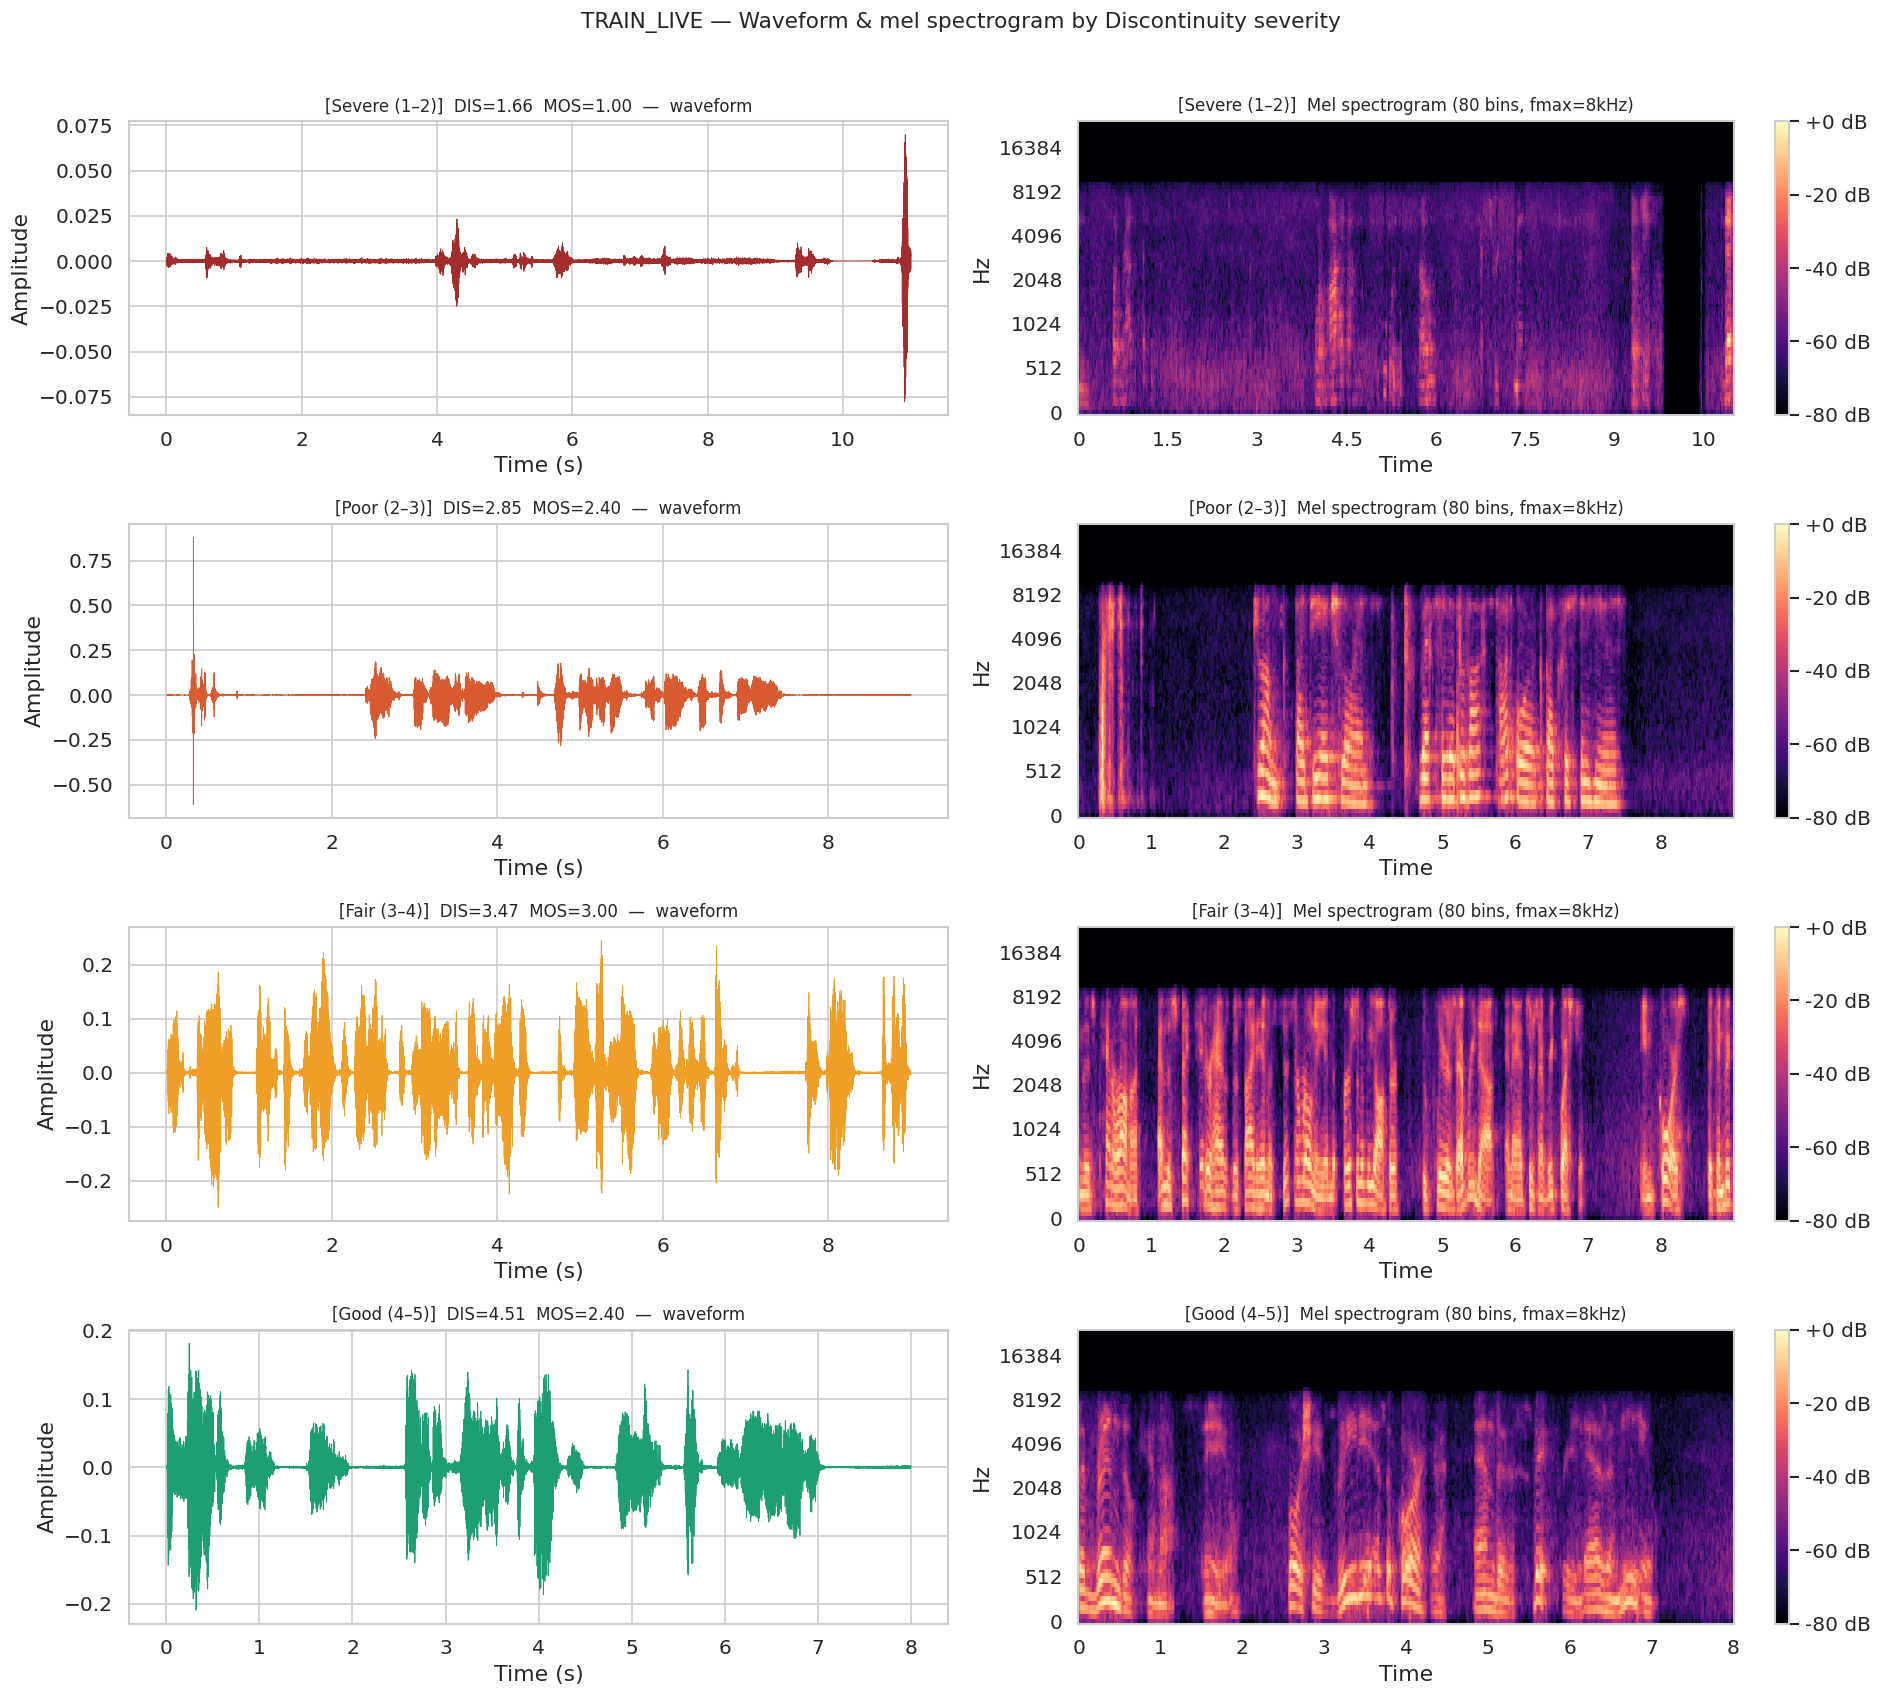

In [30]:
buckets   = ["Severe (1–2)", "Poor (2–3)", "Fair (3–4)", "Good (4–5)"]
bucket_colors = ["#A32D2D", "#D85A30", "#EF9F27", "#1D9E75"]

fig, axes = plt.subplots(len(buckets), 2, figsize=(16, 14))

for i, bucket in enumerate(buckets):
    subset = train_live[train_live["dis_bucket"] == bucket]
    if len(subset) == 0:
        axes[i][0].set_visible(False)
        axes[i][1].set_visible(False)
        continue

    # Pick a random sample from this bucket
    row   = subset.sample(1, random_state=SEED + i).iloc[0]
    fpath = DEG_DIR / row["filename_deg"]

    try:
        y, sr = librosa.load(str(fpath), sr=None)
    except Exception as e:
        print(f"Could not load {fpath.name}: {e}")
        continue

    # 6.1 Waveform
    t = np.linspace(0, len(y) / sr, len(y))
    axes[i][0].plot(t, y, color=bucket_colors[i], linewidth=0.5)
    axes[i][0].set_title(
        f"[{bucket}]  DIS={row['dis']:.2f}  MOS={row['mos']:.2f}  —  waveform",
        fontsize=10
    )
    axes[i][0].set_xlabel("Time (s)")
    axes[i][0].set_ylabel("Amplitude")

    # 6.2 Mel spectrogram
    S    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80, fmax=8000)
    S_db = librosa.power_to_db(S, ref=np.max)
    img  = librosa.display.specshow(
        S_db, sr=sr, x_axis="time", y_axis="mel",
        ax=axes[i][1], cmap="magma"
    )
    axes[i][1].set_title(f"[{bucket}]  Mel spectrogram (80 bins, fmax=8kHz)", fontsize=10)
    fig.colorbar(img, ax=axes[i][1], format="%+2.0f dB")

plt.suptitle("TRAIN_LIVE — Waveform & mel spectrogram by Discontinuity severity",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Section 6 — Key Insights

**Severe (DIS=1.66, MOS=1.00): the waveform is almost entirely silence.**
The file contains only two brief bursts of audible speech in ~11 seconds, with large
dead zones in between. In the mel spectrogram, these dead zones appear as complete
blackouts across all frequency bins — not attenuated signal but total absence.
This is a worst-case inpainting scenario: the model has almost no surrounding context
to reconstruct from. Files like this should either be excluded from training or used
exclusively as hard-negative examples.

**Poor (DIS=2.85, MOS=2.40): bursty dropout pattern with speech intact between gaps.**
The waveform shows clear segmentation — speech bursts separated by silence — suggesting
burst packet loss rather than random dropout. In the spectrogram, vertical dark bands
appear at regular intervals. This is the most structurally informative degradation pattern
for inpainting: the model can use the intact speech bursts as bidirectional context.

**Fair (DIS=3.47, MOS=3.00): continuous speech, codec coloration visible.**
The waveform looks largely intact with no obvious silence gaps. Degradation is visible
in the spectrogram as horizontal spectral suppression in the high-frequency bands (>4kHz)
and temporal smearing. This confirms the Section 4 finding — at moderate DIS scores,
the dominant artifact is coloration, not dropout. Inpainting alone will not help here.

**Good (DIS=4.51, MOS=2.40): intact signal but low MOS — loudness is the culprit.**
This is the most important observation in the spectral analysis. The waveform is clean
and continuous, the spectrogram shows full-bandwidth speech with no visible gaps — yet
MOS is only 2.40. The disconnect between high DIS and low MOS is explained by loudness
collapse: the overall signal energy is low, which the human raters penalized heavily.
This directly validates the correlation finding (r=0.76 between loudness and MOS) and
confirms that **a Good-DIS file can still be a bad-MOS file.** Our inpainting model
should not be evaluated purely on DIS improvement — it must be paired with loudness
normalization to move the MOS needle.